In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
import re

In [2]:
# cargar datos
df_abc = pd.read_csv('../files/hr_clean.csv')

# Análisis de INTERACCIONES

🎯 Objetivo

Responder a esta pregunta clave: ¿El efecto de ciertas variables sobre Attrition es igual para todos los empleados, o depende del perfil?

## Interacción OverTime × JobRole

¿En qué perfiles OverTime es especialmente crítico?

In [3]:
# FILTRAR EMPLEADOS CON HORAS EXTRA

df_ot_yes = df_abc[df_abc['over_time'] == 'Yes']

In [4]:
# Attrition por JobRole SOLO para OverTime = Yes

pd.crosstab(
    df_ot_yes['job_role'],
    df_ot_yes['attrition'],
    normalize='index'
) * 100


attrition,No,Yes
job_role,,
Healthcare Representative,94.594595,5.405405
Human Resources,66.666667,33.333333
Laboratory Technician,47.457627,52.542373
Manager,85.185185,14.814815
Manufacturing Director,89.189189,10.810811
Research Director,95.454545,4.545455
Research Scientist,65.263158,34.736842
Sales Executive,67.391304,32.608696
Sales Representative,33.333333,66.666667


### OBSERVACIÓN

Se observa que, entre los empleados que realizan horas extra, la proporción de Attrition varía notablemente según el rol, destacando tasas especialmente elevadas en perfiles como Sales Representative y Laboratory Technician, mientras que roles de mayor responsabilidad presentan niveles de rotación considerablemente más bajos.

### INTERPRETACIÓN

El análisis sugiere que el impacto de las horas extra sobre la rotación no es homogéneo y actúa como un factor amplificador del riesgo de Attrition en determinados roles operativos y comerciales, mientras que en otros roles su efecto es más limitado.

In [5]:
# Comparar con OverTime = No

df_ot_no = df_abc[df_abc['over_time'] == 'No']

pd.crosstab(
    df_ot_no['job_role'],
    df_ot_no['attrition'],
    normalize='index'
) * 100


attrition,No,Yes
job_role,,
Healthcare Representative,92.553191,7.446809
Human Resources,78.048780,21.951220
Laboratory Technician,84.500000,15.500000
Manager,98.666667,1.333333
Manufacturing Director,94.495413,5.504587
Research Director,98.275862,1.724138
Research Scientist,92.929293,7.070707
Sales Executive,88.510638,11.489362
Sales Representative,71.186441,28.813559


### OBSERVACIÓN

El rol de Sales Representative presenta tasas de Attrition elevadas tanto en presencia como en ausencia de horas extra, lo que indica que el riesgo de rotación en este perfil no depende exclusivamente de la realización de OverTime, sino que podría estar asociado a otras características propias del puesto.

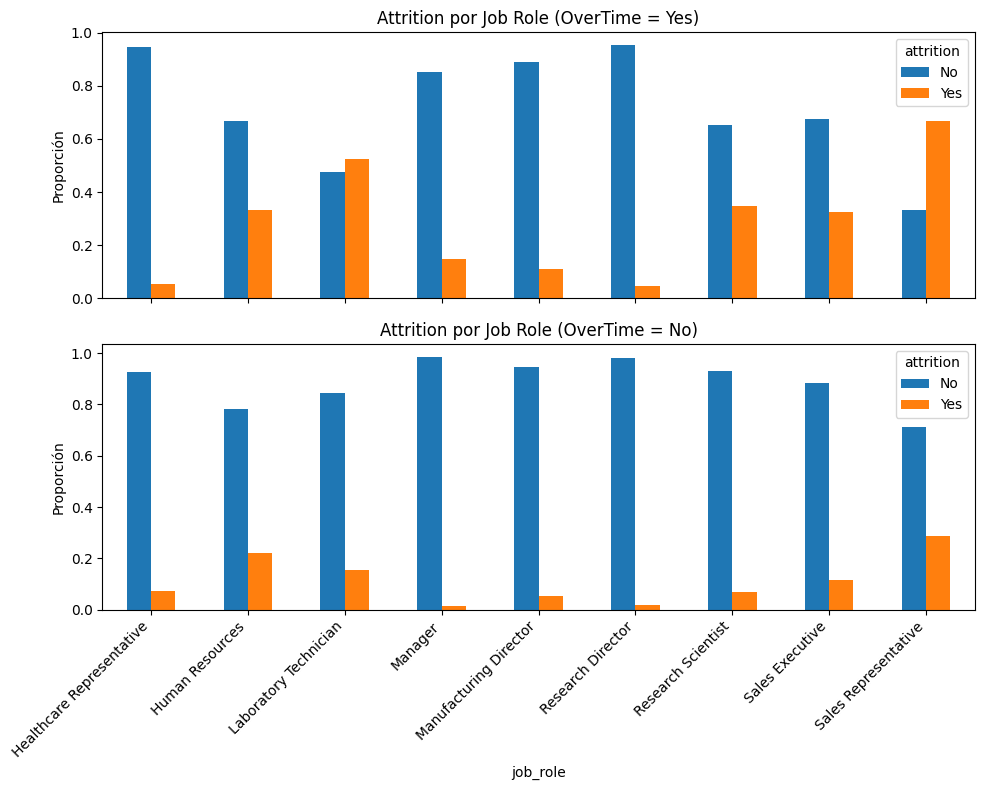

In [ ]:
# Visualizaciones

fig, axes = plt.subplots(2, 1, figsize=(10,8), sharex=True)

# OverTime = Yes
pd.crosstab(
    df_ot_yes['job_role'],
    df_ot_yes['attrition'],
    normalize='index'
).plot(kind='bar', ax=axes[0])
axes[0].set_title('Attrition por Job Role (OverTime = Yes)')
axes[0].set_ylabel('Proporción')

# OverTime = No
pd.crosstab(
    df_ot_no['job_role'],
    df_ot_no['attrition'],
    normalize='index'
).plot(kind='bar', ax=axes[1])
axes[1].set_title('Attrition por Job Role (OverTime = No)')
axes[1].set_ylabel('Proporción')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('../outputs/interacciones/attrition_jobRole_overTime', bbox_inches='tight')
plt.show()

### OBSERVACIONES

Lectura clara del patrón (qué muestra el gráfico)

🔥 Hallazgo principal: Hallazgo principal: El impacto del OverTime sobre la rotación de empleados no es homogéneo y varía significativamente según el rol desempeñado.

🟥 Roles especialmente sensibles al OverTime: Sales Representative, Laboratory Technician, Human Resources y Sales Executive.

👉 La proporción de Attrition: aumenta mucho cuando hay OverTime, y en algunos casos se observa un incremento muy acusado (Sales Representative). Aquí OverTime actúa claramente como factor amplificador.


🟨 Roles con Attrition elevado incluso sin OverTime: Sales Representative. Incluso sin horas extra, la rotación ya es alta; con OverTime, pasa a ser crítica

Esto apunta a un riesgo estructural del rol, no solo a la carga horaria.


🟩 Roles poco sensibles al OverTime: En cambio, roles como: Manager, Research Director, Manufacturing Director y Healthcare Representative, mantienen niveles bajos de Attrition, tanto con OverTime como sin OverTime.

En estos roles, el OverTime no parece actuar como un factor determinante de la rotación.

### INTERPRETACIÓN

La comparación visual entre empleados que realizan y no realizan horas extra evidencia que el efecto del OverTime sobre la rotación varía significativamente según el rol desempeñado. En determinados perfiles operativos y comerciales, la realización de horas extra se asocia a un incremento notable de la proporción de Attrition, actuando como un factor amplificador del riesgo de abandono.

Asimismo, se observa que algunos roles, como Sales Representative, presentan tasas elevadas de rotación incluso en ausencia de horas extra, lo que sugiere que el riesgo asociado a estos perfiles no depende exclusivamente del OverTime, sino también de otras características propias del puesto.

Cabe señalar que algunos roles presentan tamaños muestrales reducidos, por lo que las diferencias observadas deben interpretarse con cautela, especialmente en aquellos perfiles con menor representación.

### Resumen del análisis de interacciones 

El análisis adicional de interacciones pone de manifiesto que el efecto de determinadas variables sobre la rotación de empleados no es uniforme, sino que depende del perfil del empleado y del rol desempeñado. En particular, la interacción entre OverTime y JobRole revela que las horas extra actúan como un factor amplificador del riesgo de Attrition en determinados perfiles operativos y comerciales.

Asimismo, se identifica que algunos roles, como Sales Representative, presentan niveles elevados de rotación incluso en ausencia de horas extra, lo que sugiere la existencia de un riesgo estructural asociado al propio diseño del puesto más allá de la carga horaria.

Este enfoque permite pasar de un análisis por variables aisladas a la identificación de perfiles de mayor riesgo, aportando una visión más accionable y orientada a la toma de decisiones en materia de retención del talento.

Este análisis tiene un carácter exploratorio y se centra en identificar patrones y perfiles de riesgo, sin pretender establecer relaciones causales entre las variables analizadas.

## Segmentación exploratoria de perfiles de riesgo

La combinación de las variables analizadas permite identificar perfiles de empleados con distintos niveles de exposición al riesgo de rotación, lo que facilita una lectura más integrada de los resultados obtenidos.

A partir de los resultados del análisis exploratorio y del estudio de interacciones, se propone una segmentación simple de empleados basada en la combinación de variables con mayor asociación con la rotación: realización de horas extra (OverTime), frecuencia de viajes laborales (BusinessTravel) y rol desempeñado (JobRole).

🟥 Perfil de alto riesgo: 

    OverTime = Yes

    BusinessTravel = Travel Frequently

    JobRole operativos o comerciales (p. ej. Sales Representative, Laboratory Technician)

👉 Alta probabilidad de Attrition.


🟨 Perfil de riesgo intermedio:

    OverTime = No

    BusinessTravel = Travel Rarely

    Roles operativos o comerciales

👉 Riesgo moderado, sensible a cambios en carga de trabajo.


🟩 Perfil de bajo riesgo:

    OverTime = No

    BusinessTravel = Non Travel

    Roles senior o directivos (Manager, Research Director, Manufacturing Director)

👉 Alta estabilidad laboral.

Esta segmentación exploratoria permite identificar perfiles de empleados con distintos niveles de riesgo de rotación y pone de manifiesto la necesidad de diseñar estrategias de retención diferenciadas, en lugar de aplicar políticas homogéneas a toda la organización.

Cabe destacar que esta segmentación tiene un carácter exploratorio y no pretende sustituir a modelos predictivos, sino servir como una herramienta inicial de apoyo a la toma de decisiones.

La identificación de estos perfiles de riesgo permite orientar de forma más precisa las estrategias de retención, dando paso a un conjunto de recomendaciones basadas en los resultados del análisis.

Esta segmentación no pretende clasificar a los empleados de forma rígida, sino servir como una herramienta orientativa para priorizar acciones de retención en aquellos perfiles más expuestos.

## Recomendaciones finales a la empresa

🎯 Enfoque general

La rotación de empleados no debe abordarse como un fenómeno homogéneo, sino mediante estrategias diferenciadas según el perfil del empleado, el rol desempeñado y las condiciones del puesto.


🔹 1. Actuar sobre la carga operativa en perfiles sensibles

Basado en: OverTime - BusinessTravel - Interacción OverTime × JobRole

Sugerencias:

1.- Monitorizar horas extra de forma proactiva en roles operativos y comerciales.

2.- Introducir medidas compensatorias (flexibilidad, descanso, rotación de tareas).

3.- Evaluar la sostenibilidad de la carga de trabajo en posiciones críticas.

👉 Objetivo: reducir el efecto amplificador del OverTime en la rotación.



🔹 2. Intervenir específicamente en roles de alto riesgo

Basado en: JobRole - Segmentación implícita

Sugerencias:

1.- Diseñar planes de retención específicos para roles como Sales Representative y Laboratory Technician.

2.- Reforzar procesos de onboarding y acompañamiento temprano.

3.- Revisar expectativas del rol frente a la realidad operativa del puesto.

👉 Objetivo: reducir la rotación estructural en roles clave.



🔹 3. Reforzar la estabilidad en etapas tempranas

Basado en: Antigüedad - Nivel jerárquico - Correlaciones con experiencia y salario

Sugerencias:

1.- Definir itinerarios de crecimiento claros desde los primeros años.

2.- Comunicar oportunidades de desarrollo de forma transparente.

3.- Invertir en formación y mentoring en perfiles junior.

👉 Objetivo: disminuir la rotación temprana y aumentar el compromiso.



🔹 4. Evitar enfoques basados en variables con bajo impacto

Basado en: Género - Educación - Education Field

Sugerencia:

1.- No priorizar acciones de retención basadas exclusivamente en estas variables. Utilizarlas solo como contexto, no como criterio de decisión.

👉 Objetivo: centrar recursos en factores realmente accionables.



🔹 5. Próximos pasos recomendados

Profundizar en la segmentación de perfiles de riesgo.

Desarrollar modelos predictivos sencillos para anticipar Attrition.

Complementar el análisis cuantitativo con información cualitativa (encuestas, entrevistas).


## CIERRE FINAL

En conclusión, el análisis realizado sugiere que la rotación de empleados no es un problema individual, sino el resultado de cómo están diseñados determinados roles y condiciones de trabajo. La identificación de perfiles de mayor riesgo permite orientar estrategias de retención más focalizadas, eficientes y alineadas con la realidad organizativa.